# Notebook 2 — Re-treinamento, Validação e Online Learning

## Aula 3: Estratégias de Mitigação de Drift

### Objetivos
- Treinar modelo **baseline** no regime estável (Período 1) e medir degradação sob drift
- Implementar **re-treinamento com janela deslizante** (sliding window)
- Aplicar estratégia **champion/challenger** (shadow mode)
- Treinar modelo **online com ADWIN** (River) para mitigação contínua

### Teoria-Chave (Documento 04)

> "A escolha da janela de atualização é central: curta o suficiente para captar  
> a nova realidade, longa o suficiente para evitar decisões precipitadas."  
> — Lu et al. (2019); Provost & Fawcett (2013)

### Vídeos Relacionados
- **Vídeo 2** — Re-treinamento, Validação e Deploy Seguro (18 min)
- **Vídeo 3** — Online Learning e Detecção Adaptativa com River (20 min)

In [2]:
# Imports
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, str(Path.cwd().parent))

from src.data_preprocessing import DataPreprocessor
from src.model import BatchChurnModel, OnlineChurnModel
from src.training import (
    train_model,
    cross_validate,
    retrain_sliding_window,
    champion_challenger,
    train_online,
    df_to_stream,
)
from src.evaluation import calculate_metrics
from src.utils import save_model, save_metrics, ensure_dirs

sns.set_theme(style="whitegrid")
%matplotlib inline

# Cria diretórios de saída
ensure_dirs()

## 1. Preparação dos Dados

Carregamos o dataset, limpamos e separamos por período temporal.  
O modelo baseline será treinado apenas no **Período 1 (regime estável)**.

In [3]:
# Carrega e prepara dados
preprocessor = DataPreprocessor(seed=42)
data_path = Path.cwd().parent / "data" / "raw" / "dataset.csv"

if data_path.exists():
    df = preprocessor.load_data(str(data_path))
else:
    df = preprocessor.generate_and_save()

df = preprocessor.clean_data(df)
periods = preprocessor.split_by_period(df)

print("Amostras por período:")
for p, df_p in periods.items():
    print(f"  Período {p}: {len(df_p)} amostras, churn = {df_p['churn'].mean():.2%}")

Amostras por período:
  Período 1: 3000 amostras, churn = 11.77%
  Período 2: 3000 amostras, churn = 28.20%
  Período 3: 3000 amostras, churn = 19.70%


## 2. Modelo Baseline — Treinamento no Período 1

Conforme discutido na seção *Saiba Mais*:
> "O modelo de churn foi treinado em uma fase de relativa estabilidade  
> competitiva e aprendeu correlações coerentes com aquele período."

In [4]:
# Treina baseline no Período 1
X_p1, y_p1 = preprocessor.prepare_features(periods[1])
X_train, X_test, y_train, y_test = preprocessor.split_data(X_p1, y_p1)

baseline = train_model(X_train, y_train, model_type="logistic")
baseline_scores = baseline.score(X_test, y_test)

print("Baseline (Período 1 — regime estável):")
for metric, value in baseline_scores.items():
    print(f"  {metric}: {value:.4f}")

Baseline (Período 1 — regime estável):
  accuracy: 0.8817
  f1: 0.0000
  auc_roc: 0.6418


## 3. Degradação sob Drift

Avaliamos o baseline nos períodos 2 e 3 para medir o impacto do drift.  
Conforme Vídeo 1: linha do tempo T0→T3 mostra degradação progressiva.

Baseline → Período 1: {'accuracy': 0.8823333333333333, 'f1': 0.0, 'auc_roc': 0.6487819339013325}
Baseline → Período 2: {'accuracy': 0.718, 'f1': 0.0, 'auc_roc': 0.6416875744944257}
Baseline → Período 3: {'accuracy': 0.803, 'f1': 0.0, 'auc_roc': 0.6617071205764621}


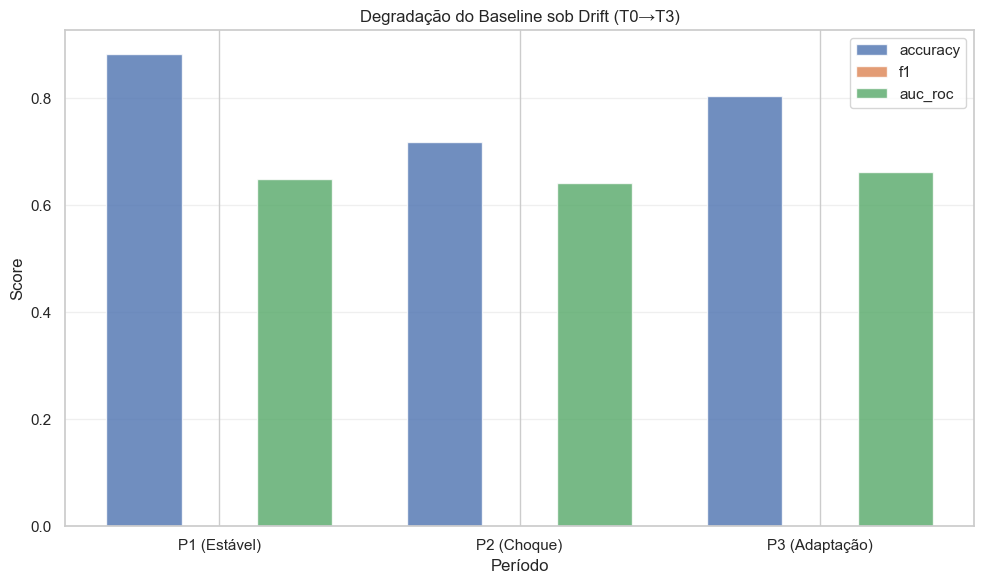

In [5]:
# Avaliar baseline em cada período
metrics_by_period = {}
for period in [1, 2, 3]:
    X_p, y_p = preprocessor.prepare_features(periods[period])
    scores = baseline.score(X_p, y_p)
    metrics_by_period[period] = scores
    print(f"Baseline → Período {period}: {scores}")

# Visualização da degradação
fig, ax = plt.subplots(figsize=(10, 6))
metric_names = list(metrics_by_period[1].keys())
x = np.arange(3)
width = 0.25

for i, metric in enumerate(metric_names):
    values = [metrics_by_period[p][metric] for p in [1, 2, 3]]
    ax.bar(x + i * width, values, width, label=metric, alpha=0.8)

ax.set_xlabel("Período")
ax.set_ylabel("Score")
ax.set_title("Degradação do Baseline sob Drift (T0→T3)")
ax.set_xticks(x + width)
ax.set_xticklabels(["P1 (Estável)", "P2 (Choque)", "P3 (Adaptação)"])
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("../outputs/figures/baseline_degradation.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Cross-Validation no Período 1

Conforme seção *Saiba Mais*: validação robusta é essencial antes de comparar  
estratégias de mitigação.

In [6]:
# Cross-validation estratificada
cv_results = cross_validate(X_p1, y_p1, model_type="logistic", n_folds=5)

print("Cross-Validation (5-fold) no Período 1:")
for metric, scores in cv_results.items():
    print(f"  {metric}: {scores.mean():.4f} ± {scores.std():.4f}")

Cross-Validation (5-fold) no Período 1:
  accuracy: 0.8823 ± 0.0008
  f1: 0.0000 ± 0.0000
  roc_auc: 0.6317 ± 0.0424


## 5. Re-treinamento com Janela Deslizante

Implementa a estratégia reativa discutida na seção *Saiba Mais*:  
> "Sua força está em permitir que o modelo reaprenda a fronteira de decisão  
> usando dados que refletem o regime estatístico atual."

A janela desliza sobre o dataset ordenado temporalmente, re-treinando  
o modelo a cada passo e avaliando no bloco seguinte.

In [7]:
# Re-treinamento com janela deslizante
feature_cols = [
    "tenure_months", "monthly_charges", "total_charges",
    "data_usage_gb", "call_duration_min", "num_complaints",
    "payment_delay_days", "contract_type", "has_premium_support",
    "competitor_offer_exposure", "customer_value_segment",
]

sliding_results = retrain_sliding_window(
    df, feature_cols=feature_cols, target_col="churn",
    window_size=2000, step_size=500, model_type="logistic"
)

print(f"Janelas avaliadas: {len(sliding_results)}")
for i, r in enumerate(sliding_results[:5]):
    print(f"  Janela {i}: F1={r['f1']:.4f}, AUC={r['auc_roc']:.4f}")

c:\Personal\Others\FIAP\POSTECH-DATA_DRIFT\9mlet-data-drift\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Personal\Others\FIAP\POSTECH-DATA_DRIFT\9mlet-data-drift\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as s

Janelas avaliadas: 13
  Janela 0: F1=0.0000, AUC=0.6291
  Janela 1: F1=0.0000, AUC=0.6061
  Janela 2: F1=0.0000, AUC=0.6331
  Janela 3: F1=0.1778, AUC=0.6618
  Janela 4: F1=0.1808, AUC=0.6687


c:\Personal\Others\FIAP\POSTECH-DATA_DRIFT\9mlet-data-drift\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


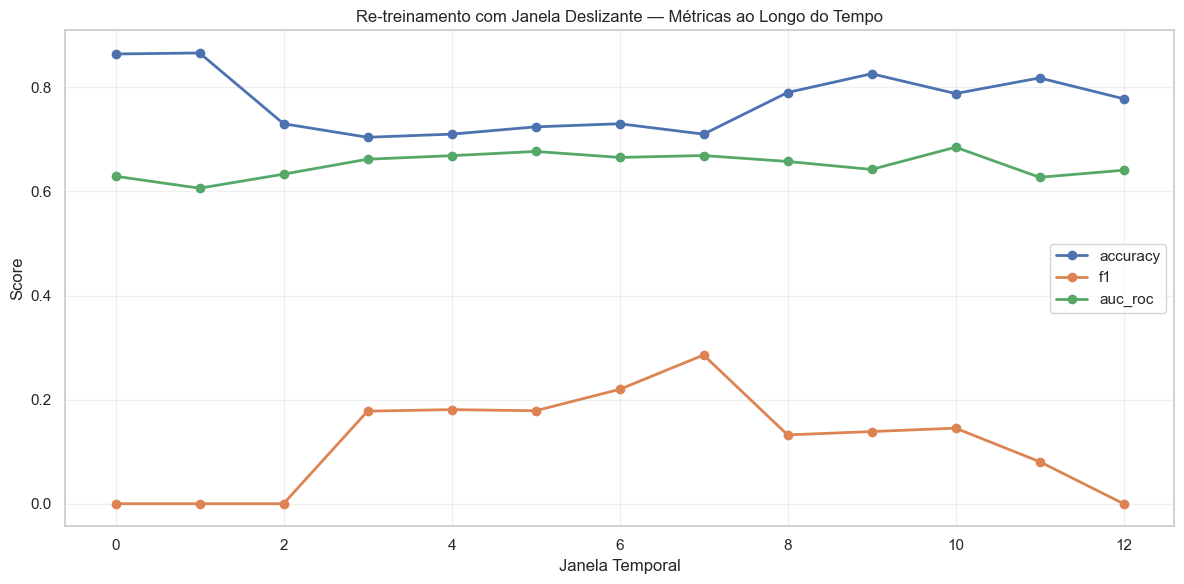

In [8]:
# Visualização do re-treinamento com janela deslizante
fig, ax = plt.subplots(figsize=(12, 6))

for metric in ["accuracy", "f1", "auc_roc"]:
    values = [r[metric] for r in sliding_results]
    ax.plot(range(len(values)), values, marker="o", label=metric, linewidth=2)

ax.set_xlabel("Janela Temporal")
ax.set_ylabel("Score")
ax.set_title("Re-treinamento com Janela Deslizante — Métricas ao Longo do Tempo")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../outputs/figures/sliding_window_metrics.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Champion/Challenger (Shadow Mode)

Conforme Vídeo 2: antes de substituir o modelo em produção, rodamos  
champion e challenger em paralelo para comparar desempenho.

> "A pergunta correta não é 'o novo modelo está melhor em média?',  
> mas sim 'ele está melhor nos segmentos críticos?'"  
> — Provost & Fawcett (2013)

In [9]:
# Champion (dados P1) vs Challenger (dados P2)
X_p2, y_p2 = preprocessor.prepare_features(periods[2])
X_p3, y_p3 = preprocessor.prepare_features(periods[3])

result = champion_challenger(
    X_train_old=X_p1, y_train_old=y_p1,
    X_train_new=X_p2, y_train_new=y_p2,
    X_test=X_p3, y_test=y_p3,
    model_type="logistic",
)

print("Champion (treino P1) → teste P3:")
for m, v in result["champion_metrics"].items():
    print(f"  {m}: {v:.4f}")

print("\nChallenger (treino P2) → teste P3:")
for m, v in result["challenger_metrics"].items():
    print(f"  {m}: {v:.4f}")

Champion (treino P1) → teste P3:
  accuracy: 0.8030
  f1: 0.0000
  auc_roc: 0.6543

Challenger (treino P2) → teste P3:
  accuracy: 0.7863
  f1: 0.2057
  auc_roc: 0.6719


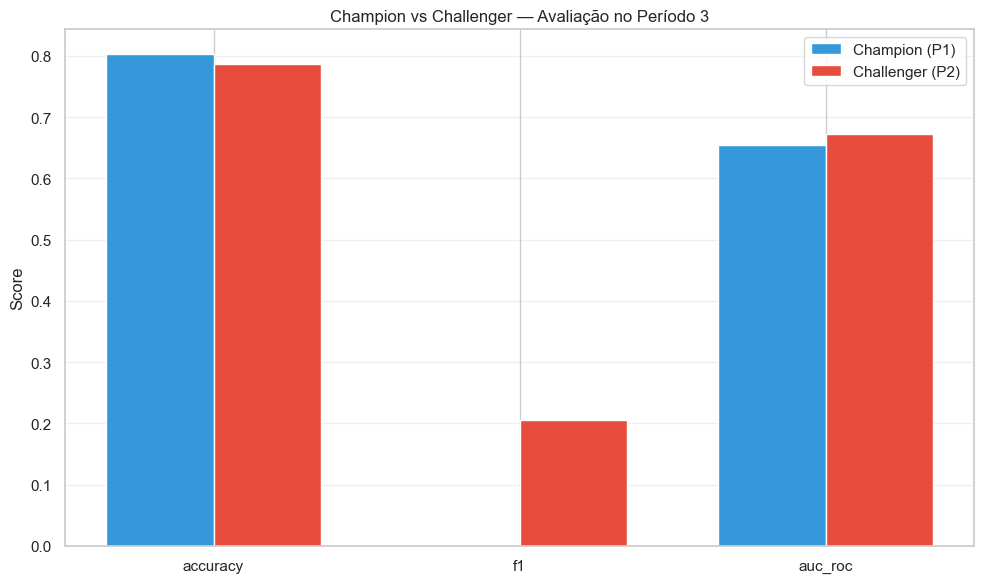

In [10]:
# Comparação visual Champion vs Challenger
fig, ax = plt.subplots(figsize=(10, 6))
metrics_names = list(result["champion_metrics"].keys())
x = np.arange(len(metrics_names))
width = 0.35

champion_vals = [result["champion_metrics"][m] for m in metrics_names]
challenger_vals = [result["challenger_metrics"][m] for m in metrics_names]

ax.bar(x - width/2, champion_vals, width, label="Champion (P1)", color="#3498db")
ax.bar(x + width/2, challenger_vals, width, label="Challenger (P2)", color="#e74c3c")

ax.set_ylabel("Score")
ax.set_title("Champion vs Challenger — Avaliação no Período 3")
ax.set_xticks(x)
ax.set_xticklabels(metrics_names)
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("../outputs/figures/champion_vs_challenger.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Aprendizado Online com ADWIN (River)

Implementa o gatilho mínimo de detecção da seção *Hands On* (Snippet 1):
```python
from river import drift
detector = drift.ADWIN()
for i, value in enumerate(stream):
    detector.update(value)
    if detector.drift_detected:
        print(f"Drift detectado em {i}")
```

Conforme Bifet & Gavaldà (2007): ADWIN mantém janela adaptativa que  
encolhe quando detecta mudança estatística significativa.

In [11]:
# Treinamento online com detecção de drift
stream = df_to_stream(df.sort_values("timestamp_month"), feature_cols)
online_model = train_online(stream, seed=42)

print(f"Amostras processadas: {online_model.n_samples_seen}")
print(f"Drifts detectados: {len(online_model.drift_points)}")
print(f"Acurácia acumulada: {online_model.accuracy:.4f}")

if online_model.drift_points:
    print(f"Pontos de drift: {online_model.drift_points[:10]}")

Amostras processadas: 9000
Drifts detectados: 2
Acurácia acumulada: 0.7992
Pontos de drift: [3168, 6784]


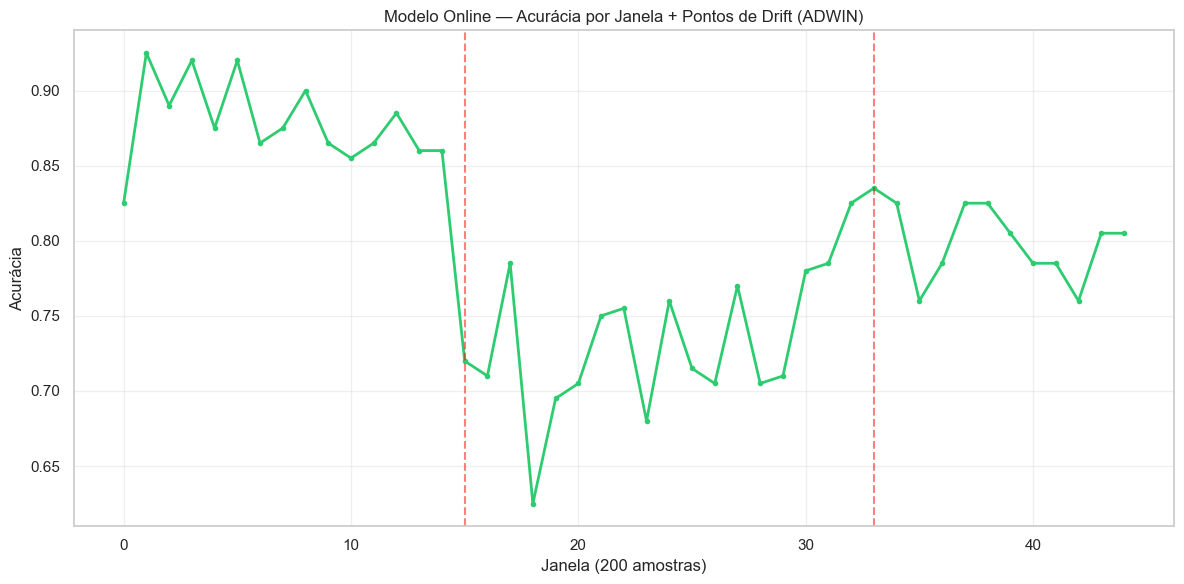

In [12]:
# Visualização da acurácia online com pontos de drift
# Re-calculamos acurácia em janelas para visualização
online_viz = OnlineChurnModel(seed=42)
window_acc = []
window_size = 200
correct_window = 0
total_window = 0

for i, (x, y) in enumerate(stream):
    pred = online_viz.predict_one(x)
    if pred is not None:
        correct_window += int(pred == y)
    total_window += 1
    online_viz.learn_one(x, y)

    if (i + 1) % window_size == 0:
        acc = correct_window / total_window if total_window > 0 else 0
        window_acc.append(acc)
        correct_window = 0
        total_window = 0

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(range(len(window_acc)), window_acc, marker=".", linewidth=2, color="#2ecc71")

# Marcar drifts
for dp in online_viz.drift_points:
    window_idx = dp // window_size
    if window_idx < len(window_acc):
        ax.axvline(window_idx, color="red", linestyle="--", alpha=0.5)

ax.set_xlabel(f"Janela ({window_size} amostras)")
ax.set_ylabel("Acurácia")
ax.set_title("Modelo Online — Acurácia por Janela + Pontos de Drift (ADWIN)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../outputs/figures/online_accuracy_with_drift.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Salvar Modelos e Métricas

Serializamos os modelos para uso no Notebook 03 (Avaliação).

In [13]:
# Salvar modelos
save_model(baseline, Path.cwd().parent / "outputs" / "models" / "baseline_logistic.joblib")
save_model(online_model, Path.cwd().parent / "outputs" / "models" / "online_adwin.joblib")

# Salvar métricas
all_metrics = {
    "baseline_per_period": {str(k): v for k, v in metrics_by_period.items()},
    "champion_challenger": {
        "champion": result["champion_metrics"],
        "challenger": result["challenger_metrics"],
    },
    "online_model": {
        "accuracy": online_model.accuracy,
        "n_drifts": len(online_model.drift_points),
    },
}
save_metrics(all_metrics, Path.cwd().parent / "outputs" / "logs" / "training_metrics.json")
print("Modelos e métricas salvos.")

Modelos e métricas salvos.


## Resumo

Neste notebook implementamos:

1. **Baseline** treinado no período estável, com degradação progressiva sob drift
2. **Re-treinamento com janela deslizante** — captura a nova realidade gradualmente
3. **Champion/Challenger** — comparação segura entre modelos antigo e atualizado
4. **Modelo online com ADWIN** — adaptação contínua com detecção de drift

### Próximo Notebook
No **Notebook 03 — Avaliação e Ensembles Adaptativos**, implementaremos:
- ADWINBoostingClassifier (ensemble adaptativo)
- Limiar ótimo sensível a custo
- Comparação completa de todas as estratégias de mitigação